# DDI Dataset Construction

DrugBank XML to labeled pairs, PK features, DDInter cross-reference. Writes processed CSVs consumed by training and evaluation.

## Setup

Imports and paths via `ProjectConfig` for consistency with training code.

In [1]:
%matplotlib inline
import re
import sys
import time
import xml.etree.ElementTree as ET
from itertools import chain
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Lipinski

notebook_start = time.time()
RDLogger.DisableLog("rdApp.*")

sys.path.insert(0, str(Path().resolve().parent / "src"))
from config import ProjectConfig
from feature_engineering import ddi_merged, negative_pairs
from stratify import split_pairs

cfg = ProjectConfig()
SEED = cfg.train.seed
XML_PATH = cfg.paths.raw / "full database.xml"
PROCESSED = cfg.paths.processed
PLOTS = cfg.paths.plots / "eda"
NS = {"db": "http://www.drugbank.ca"}

PROCESSED.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

## DrugBank XML parse

Per-drug SMILES, enzyme/transporter roles, interaction records.

In [2]:
def smiles_field(drug, ns):
    el = drug.find('.//db:calculated-properties/db:property[db:kind="SMILES"]/db:value', ns)
    return el.text if el is not None else None


def pk_roles(drug, ns, tag):
    """Enzyme or transporter roles from XML block."""
    parent, child = tag.split("/")
    roles = {}
    for el in drug.findall(f".//db:{parent}/db:{child}", ns):
        name = el.findtext("db:name", namespaces=ns)
        actions = [a.text for a in el.findall("db:actions/db:action", ns) if a.text]
        if name:
            roles[name] = actions
    return roles


def interaction_records(drug, ns):
    return [
        (ix.findtext("db:drugbank-id", namespaces=ns),
         ix.findtext("db:name", namespaces=ns),
         ix.findtext("db:description", namespaces=ns) or "")
        for ix in drug.findall(".//db:drug-interactions/db:drug-interaction", ns)
    ]


def drugbank_drugs(xml_path, ns):
    """Parse all drugs from DrugBank XML."""
    root = ET.parse(xml_path).getroot()
    return [{
        "drugbank_id": d.findtext('db:drugbank-id[@primary="true"]', namespaces=ns),
        "name": d.findtext("db:name", namespaces=ns),
        "smiles": smiles_field(d, ns),
        "enzymes": pk_roles(d, ns, "enzymes/enzyme"),
        "transporters": pk_roles(d, ns, "transporters/transporter"),
        "interactions": interaction_records(d, ns),
    } for d in root.findall("db:drug", ns)]

In [3]:
drugs = drugbank_drugs(XML_PATH, NS)
drug_map = {d["drugbank_id"]: d for d in drugs if d["drugbank_id"]}
id_to_name = {d["drugbank_id"]: d["name"] for d in drugs if d["drugbank_id"]}
name_to_id = {d["name"].lower(): d["drugbank_id"] for d in drugs if d["name"]}

n_smiles = sum(1 for d in drugs if d["smiles"])
n_interactions = sum(len(d["interactions"]) for d in drugs)
print(f"Drugs: {len(drugs):,}  SMILES: {n_smiles:,}  Interactions: {n_interactions:,}")


Drugs: 19,853  SMILES: 14,623  Interactions: 2,913,002


## Pair extraction and labeling

Dedupe pairs via canonical sorted IDs. Severity from keyword match, mechanism from regex over description text.

In [4]:
def deduplicated_pairs(drug_map):
    """Unique drug pairs with descriptions, sorted IDs prevent duplicates."""
    seen, rows = set(), []
    for did, d in drug_map.items():
        for pid, _, desc in d["interactions"]:
            pair = tuple(sorted([did, pid]))
            if pair not in seen:
                seen.add(pair)
                rows.append({"drug_a": pair[0], "drug_b": pair[1], "description": desc})
    return pd.DataFrame(rows)


df_pairs = deduplicated_pairs(drug_map)
print(f"Unique pairs: {len(df_pairs):,}")


Unique pairs: 1,456,772


In [5]:
SEVERITY_KEYWORDS = [
    "risk or severity", "serum concentration", "metabolism",
    "therapeutic efficacy", "excretion", "absorption", "activities",
]


def severity_labels(descriptions):
    """Vectorized severity from DrugBank description keywords."""
    low = descriptions.str.lower()
    labels = pd.Series("unknown", index=descriptions.index)
    for kw in SEVERITY_KEYWORDS:
        labels[low.str.contains(kw, regex=False)] = "significant"
    labels[low.str.contains("contraindicated", regex=False)] = "contraindicated"
    return labels


df_pairs["severity"] = severity_labels(df_pairs["description"])
print(df_pairs["severity"].value_counts().to_string())
print(f"Labeled: {(df_pairs['severity'] != 'unknown').mean():.1%}")


severity
significant    1452315
unknown           4457
Labeled: 99.7%


In [6]:
MECHANISM_RULES = {
    "cyp_induction": [
        "metabolism.*can be increased", "increase.*metabolism",
        "serum concentration.*can be decreased", "decrease.*serum concentration",
        "therapeutic efficacy.*can be decreased", "decrease.*therapeutic efficacy",
    ],
    "cyp_inhibition": [
        "metabolism.*can be decreased", "decrease.*metabolism",
        "serum concentration.*can be increased", "increase.*serum concentration",
    ],
    "qt_prolongation": [
        "QTc.prolonging", "prolong.*QT", "torsades", "cardiac arrhythmia",
    ],
    "additive_toxicity": [
        "risk or severity", "adverse effects.*increased",
        "central nervous system depressant",
        "hepatotoxic", "nephrotoxic", "myelosuppressive",
        "serotonin syndrome", "CNS depress",
        "bleeding", "hypotensive activities", "hypertensive activities",
        "hyperkalemi", "hypoglycemi", "ototoxic", "neuromuscular",
        "anticoagulant activities", "anticholinergic activities",
        "sedative activities",
    ],
    "absorption_interference": [
        "absorption.*can be", "decrease.*absorption",
        "chelat", "bioavailability", "gastric pH",
    ],
    "protein_binding": [
        "protein binding", "free fraction", "displace.*from.*binding",
    ],
    "excretion": [
        "excretion.*can be", "renal clearance",
    ],
}


def mechanism_flags(descriptions):
    """Boolean DataFrame of mechanism matches, vectorized per mechanism."""
    flags = pd.DataFrame(index=descriptions.index)
    for mech, patterns in MECHANISM_RULES.items():
        combined = "|".join(f"(?:{p})" for p in patterns)
        flags[mech] = descriptions.str.contains(combined, case=False, regex=True, na=False)
    return flags


def joined_mechanisms(mech_df):
    """Vectorized pipe-join of active mechanism columns."""
    cols = mech_df.columns.tolist()
    parts = [mech_df[c].map({True: c, False: ""}) for c in cols]
    joined = parts[0].str.cat(parts[1:], sep="|")
    return joined.str.strip("|").str.replace(r"\|{2,}", "|", regex=True)


df_mech = mechanism_flags(df_pairs["description"])
df_mech["other"] = ~df_mech.any(axis=1)
df_pairs["mechanisms"] = joined_mechanisms(df_mech)

mech_counts = df_mech.sum().sort_values(ascending=False)
for mech, cnt in mech_counts.items():
    print(f"  {mech:<25s}: {int(cnt):>8,} ({cnt / len(df_pairs):.1%})")
print(f"\nMulti-mechanism: {(df_mech.drop(columns='other').sum(axis=1) > 1).mean():.1%}")

  additive_toxicity        :  732,870 (50.3%)
  other                    :  277,852 (19.1%)
  cyp_inhibition           :  222,456 (15.3%)
  cyp_induction            :  209,019 (14.3%)
  absorption_interference  :   12,937 (0.9%)
  excretion                :   10,440 (0.7%)
  qt_prolongation          :    2,811 (0.2%)
  protein_binding          :    1,503 (0.1%)

Multi-mechanism: 0.9%


## Class imbalance and mechanism coverage

Severity distribution, per-mechanism positives with log-damped weights, and the unmatched (`other`) share.

In [7]:
def severity_imbalance(pair_df):
    """Severity counts and ratios relative to smallest class."""
    counts = pair_df["severity"].value_counts()
    floor = counts.min()
    print("Severity imbalance (xN = N x smallest):")
    for sev, cnt in counts.items():
        print(f"  {sev:<20s}: {cnt:>8,}  ({cnt / floor:.1f}x)")


def mechanism_balance(pos_mech_df, n_pos):
    """Per-mechanism positive count, neg/pos ratio, log-damped weight."""
    print(f"\nMechanism pos/neg (n={n_pos:,}):")
    print(f"  {'mechanism':<25s}  {'pos':>6s}  {'neg/pos':>8s}  {'log(1+r)':>10s}")
    for c in pos_mech_df.columns:
        p = int(pos_mech_df[c].sum())
        raw = (n_pos - p) / max(p, 1)
        print(f"  {c:<25s}  {p:>6,}  {raw:>8.1f}  {np.log1p(raw):>10.2f}")


def mechanism_coverage(pair_df):
    """Distribution of mechanism labels per positive interaction."""
    only_other = (pair_df["mechanisms"] == "other").sum()
    has_any = len(pair_df) - only_other
    n_mech = pair_df["mechanisms"].str.count(r"\|").add(1)
    n_mech = n_mech.where(pair_df["mechanisms"] != "other", 0)
    n = len(pair_df)
    print(f"\nMechanism coverage (n={n:,})")
    print(f"  0 mechanisms:   {only_other:>8,}  ({only_other / n:>5.1%})")
    print(f"  >=1 mechanism:  {has_any:>8,}  ({has_any / n:>5.1%})")
    for k, m in n_mech.value_counts().sort_index().items():
        print(f"    {k}: {m:>8,}  ({m / n:>5.1%})")


positive_mask = df_pairs["severity"] != "unknown"
mech_cols = [c for c in df_mech.columns if c != "other"]
pos_mech = df_mech.loc[positive_mask, mech_cols]
n_pos = positive_mask.sum()

print(f"Positives: {n_pos:,}")
print(f"  +mechanism: {pos_mech.any(axis=1).sum():,} ({pos_mech.any(axis=1).mean():.1%})")
print(f"  no mech:    {(~pos_mech.any(axis=1)).sum():,}")
severity_imbalance(df_pairs)
mechanism_balance(pos_mech, n_pos)
mechanism_coverage(df_pairs)


Positives: 1,452,315
  +mechanism: 1,176,294 (81.0%)
  no mech:    276,021
Severity imbalance (xN = N x smallest):
  significant         : 1,452,315  (325.9x)
  unknown             :    4,457  (1.0x)

Mechanism pos/neg (n=1,452,315):
  mechanism                     pos   neg/pos    log(1+r)
  cyp_induction              209,019       5.9        1.94
  cyp_inhibition             222,456       5.5        1.88
  qt_prolongation             2,811     515.7        6.25
  additive_toxicity          732,870       1.0        0.68
  absorption_interference    11,814     121.9        4.81
  protein_binding                 0  1452315.0       14.19
  excretion                  10,440     138.1        4.94

Mechanism coverage (n=1,456,772)
  0 mechanisms:    277,852  (19.1%)
  >=1 mechanism:  1,178,920  (80.9%)
    0:  277,852  (19.1%)
    1: 1,165,804  (80.0%)
    2:   13,116  ( 0.9%)


## DDInter cross-database merge

DDInter uses WHO INN (rifampicin, salbutamol); DrugBank uses American generic names (rifampin, albuterol). Exact-name merge silently drops all rifampin pairs. Alias map resolves four mismatches surfaced by the dropout diagnostic.

In [8]:
DDINTER_DIR = cfg.paths.raw / "DDInter"

DDINTER_ALIASES = {
    "rifampicin": "rifampin",
    "salbutamol": "albuterol",
    "interferon alfa-2a, recombinant": "interferon alfa-2a",
    "pfizer-biontech covid-19 vaccine": "tozinameran",
}

LEVEL_RANK = {"Major": 3, "Moderate": 2, "Minor": 1, "Unknown": 0}


def combined_ddinter(directory):
    """Concatenate all DDInter CSVs."""
    files = sorted(directory.glob("ddinter_downloads_code_*.csv"))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


def normalized_names(series):
    """Vectorized lowercase, strip parentheticals, apply alias map."""
    cleaned = series.str.replace(r"\s*\(.*?\)", "", regex=True).str.strip().str.lower()
    return cleaned.replace(DDINTER_ALIASES)


def drugbank_name_index(id_name_map):
    """Normalized drug name to DrugBank ID lookup."""
    return {re.sub(r"\s*\(.*?\)", "", n).strip().lower(): d
            for d, n in id_name_map.items()}


def canonical_pairs(dd_df, db_index):
    """Map DDInter rows to canonical DrugBank pair IDs without deduplication."""
    dd = dd_df.copy()
    dd["db_a"] = normalized_names(dd["Drug_A"]).map(db_index)
    dd["db_b"] = normalized_names(dd["Drug_B"]).map(db_index)
    dd = dd.dropna(subset=["db_a", "db_b"])
    a, b = dd["db_a"].values, dd["db_b"].values
    dd["drug_a"] = np.where(a <= b, a, b)
    dd["drug_b"] = np.where(a <= b, b, a)
    return dd[["drug_a", "drug_b", "Level"]]


def matched_pairs(dd_df, db_index):
    """Map DDInter to DrugBank IDs. Conflicting Levels resolved by max severity."""
    canon = canonical_pairs(dd_df, db_index)
    canon = canon.assign(rank=canon["Level"].map(LEVEL_RANK).fillna(-1))
    return (canon.sort_values("rank", ascending=False, kind="stable")
                 .drop_duplicates(subset=["drug_a", "drug_b"])
                 [["drug_a", "drug_b", "Level"]])


In [9]:
dd_raw = combined_ddinter(DDINTER_DIR)
db_index = drugbank_name_index(id_to_name)

canon_all = canonical_pairs(dd_raw, db_index)
levels_per_pair = canon_all.groupby(["drug_a", "drug_b"])["Level"].nunique()
n_conflicts = int((levels_per_pair > 1).sum())
print(f"DDInter raw: {len(dd_raw):,}  canonical: {len(canon_all):,}")
print(f"Multi-Level conflicts: {n_conflicts:,}")
if n_conflicts:
    conflicting = levels_per_pair[levels_per_pair > 1]
    sample_keys = conflicting.head(5).index
    sample = canon_all.set_index(["drug_a", "drug_b"]).loc[sample_keys]
    print("\nSample conflicts (resolved to max severity):")
    print(sample.head(15).to_string())

dd = matched_pairs(dd_raw, db_index)
print(f"\nDDInter matched: {len(dd):,} ({len(dd) / len(dd_raw):.1%})")
print(dd["Level"].value_counts().to_string())

overlap = df_pairs[["drug_a", "drug_b"]].merge(dd, on=["drug_a", "drug_b"], how="inner")
print(f"\nDrugBank-DDInter overlap: {len(overlap):,}")
print(overlap["Level"].value_counts().to_string())


DDInter raw: 222,383  canonical: 222,381
Multi-Level conflicts: 887

Sample conflicts (resolved to max severity):
                    Level
drug_a  drug_b           
DB00002 DB00855  Moderate
        DB00855     Major
DB00004 DB14022  Moderate
        DB14022     Major
DB00005 DB14022  Moderate
        DB14022     Major
DB00023 DB14022  Moderate
        DB14022     Major
DB00026 DB14022  Moderate
        DB14022     Major

DDInter matched: 150,419 (67.6%)
Level
Moderate    88781
Unknown     29813
Major       25721
Minor        6104

DrugBank-DDInter overlap: 93,628
Level
Moderate    57133
Major       19709
Unknown     13375
Minor        3411


In [10]:
def unmatched_names(dd_df, db_index):
    """DDInter names that fail to map to any DrugBank ID."""
    a = normalized_names(dd_df["Drug_A"])
    b = normalized_names(dd_df["Drug_B"])
    return pd.Series(list(chain(a[~a.isin(db_index)], b[~b.isin(db_index)])))


unmatched = unmatched_names(dd_raw, db_index)
print(f"Unmatched name occurrences: {len(unmatched):,} ({unmatched.nunique()} unique)")
if len(unmatched):
    print("\nTop unmatched:")
    print(unmatched.value_counts().head(10).to_string())

Unmatched name occurrences: 2 (1 unique)

Top unmatched:
manganese    2


## Pharmacokinetic feature extraction

Binary vector per drug: 8 CYP enzymes + 2 transporters (ABCB1, OATP1B1), each across 3 roles (substrate / inhibitor / inducer) = 30 columns.

In [11]:
CYP_ENZYMES = [
    "Cytochrome P450 3A4", "Cytochrome P450 2D6", "Cytochrome P450 2C19",
    "Cytochrome P450 2C9", "Cytochrome P450 1A2", "Cytochrome P450 2B6",
    "Cytochrome P450 2E1", "Cytochrome P450 2C8",
]
CYP_ROLES = ["substrate", "inhibitor", "inducer"]
TRANSPORTERS = ["ATP-dependent translocase ABCB1",
                "Solute carrier organic anion transporter family member 1B1"]
TRANSPORTER_ROLES = ["substrate", "inhibitor", "inducer"]

PK_COLS = ([f"{e}_{r}" for e in CYP_ENZYMES for r in CYP_ROLES]
           + [f"{t}_{r}" for t in TRANSPORTERS for r in TRANSPORTER_ROLES])


def pk_vector(drug_rec):
    """Binary PK feature vector from enzyme/transporter annotations."""
    vec = []
    for enz in CYP_ENZYMES:
        actions = {a.lower() for a in drug_rec.get("enzymes", {}).get(enz, [])}
        vec.extend(int(r in actions) for r in CYP_ROLES)
    for trp in TRANSPORTERS:
        actions = {a.lower() for a in drug_rec.get("transporters", {}).get(trp, [])}
        vec.extend(int(r in actions) for r in TRANSPORTER_ROLES)
    return vec


df_pk_full = pd.DataFrame.from_dict(
    {d["drugbank_id"]: pk_vector(d) for d in drugs if d["drugbank_id"]},
    orient="index", columns=PK_COLS,
)
annotated = (df_pk_full.sum(axis=1) > 0).sum()
print(f"PK matrix: {df_pk_full.shape}  annotated: {annotated:,}")


PK matrix: (19853, 30)  annotated: 1,575


## PK reconciliation

Validate columns against downstream references. Catches dimension drift before CSV write.

In [12]:
MECHANISM_TO_PK = {
    "cyp_induction":           [c for c in PK_COLS if c.endswith("_inducer")
                                and c.startswith("Cytochrome")],
    "cyp_inhibition":          [c for c in PK_COLS if c.endswith("_inhibitor")
                                and c.startswith("Cytochrome")],
    "qt_prolongation":         [],
    "additive_toxicity":       [],
    "absorption_interference": [c for c in PK_COLS if "ABCB1" in c
                                and c.endswith("_inhibitor")],
    "protein_binding":         [],
    "excretion":               [c for c in PK_COLS if ("ABCB1" in c or "1B1" in c)
                                and c.endswith("_inhibitor")],
}

assert df_pk_full.shape[1] == 30, f"expected 30 cols, got {df_pk_full.shape[1]}"
unresolved = {m: [c for c in cols if c not in df_pk_full.columns]
              for m, cols in MECHANISM_TO_PK.items() if cols}
unresolved = {m: c for m, c in unresolved.items() if c}
assert not unresolved, f"MECHANISM_TO_PK missing cols: {unresolved}"

print(f"PK shape: {df_pk_full.shape}")
print("MECHANISM_TO_PK cols:",
      {m: len(c) for m, c in MECHANISM_TO_PK.items()})


PK shape: (19853, 30)
MECHANISM_TO_PK cols: {'cyp_induction': 8, 'cyp_inhibition': 8, 'qt_prolongation': 0, 'additive_toxicity': 0, 'absorption_interference': 1, 'protein_binding': 0, 'excretion': 2}


## PK feature diagnostics

Per-column prevalence and indirect leakage analysis. Contingency reports P(flag | mechanism label) vs P(flag | unlabeled); lift > 1 means the PK flag predicts the regex-derived label.

In [13]:
def column_prevalence(pk_df):
    """Per-column flag prevalence across annotated drugs."""
    annotated = pk_df.loc[pk_df.sum(axis=1) > 0]
    print(f"PK prevalence (annotated: {len(annotated):,}/{len(pk_df):,})\n")
    for col in pk_df.columns:
        n = int(annotated[col].sum())
        print(f"  {col:<62s}  {n:>4d}  ({n / len(annotated):5.1%})")


def pair_has_flag(pair_df, pk_df, columns):
    """True per pair if drug_a OR drug_b has any listed PK flag set."""
    cols = [c for c in columns if c in pk_df.columns]
    if not cols:
        return pd.Series(False, index=pair_df.index)
    a = pk_df.reindex(pair_df["drug_a"])[cols].any(axis=1).fillna(False).values
    b = pk_df.reindex(pair_df["drug_b"])[cols].any(axis=1).fillna(False).values
    return pd.Series(a | b, index=pair_df.index)


def leakage_contingency(pair_df, pk_df, mech_to_pk, label=""):
    """For each mechanism, P(flag|label) vs P(flag|not labeled)."""
    title = f"Leakage contingency (n={len(pair_df):,})"
    if label:
        title += f"  [{label}]"
    print(f"\n{title}")
    print("  lift > 1: PK flag predicts the regex label\n")
    print(f"  {'mechanism':<25s}  {'n_pos':>6s}  {'P(flag|+)':>10s}  "
          f"{'P(flag|-)':>10s}  {'lift':>7s}  {'cols':>9s}")
    for mech, raw_cols in mech_to_pk.items():
        cols = [c for c in raw_cols if c in pk_df.columns]
        pos_mask = pair_df["mechanisms"].str.contains(mech, regex=False, na=False)
        n_pos = int(pos_mask.sum())
        col_str = f"{len(cols)}/{len(raw_cols)}"
        if not raw_cols:
            print(f"  {mech:<25s}  {n_pos:>6d}  {'no PK path':>10s}  "
                  f"{'-':>10s}  {'-':>7s}  {col_str:>9s}")
            continue
        if not cols:
            print(f"  {mech:<25s}  {n_pos:>6d}  {'dropped':>10s}  "
                  f"{'-':>10s}  {'-':>7s}  {col_str:>9s}")
            continue
        if n_pos == 0:
            print(f"  {mech:<25s}  {n_pos:>6d}  {'no positives':>22s}")
            continue
        flag = pair_has_flag(pair_df, pk_df, cols)
        p_pos = flag[pos_mask].mean()
        p_neg = flag[~pos_mask].mean()
        lift = p_pos / max(p_neg, 1e-9)
        print(f"  {mech:<25s}  {n_pos:>6d}  {p_pos:>10.1%}  "
              f"{p_neg:>10.1%}  {lift:>6.1f}x  {col_str:>9s}")


def drug_spotlight(pk_df, drug_id, label):
    """Print a single drug's active PK flags."""
    if drug_id not in pk_df.index:
        print(f"\n{label} ({drug_id}): not in pk_features")
        return
    active = pk_df.loc[drug_id]
    active = active[active > 0]
    print(f"\n{label} ({drug_id}): {len(active)}/{pk_df.shape[1]} flags active")
    for col in active.index:
        print(f"    {col}")


column_prevalence(df_pk_full)
leakage_contingency(df_pairs, df_pk_full, MECHANISM_TO_PK, label="full 30-col")
drug_spotlight(df_pk_full, "DB01045", "Rifampin")
drug_spotlight(df_pk_full, "DB00951", "Isoniazid")


PK prevalence (annotated: 1,575/19,853)

  Cytochrome P450 3A4_substrate                                    883  (56.1%)
  Cytochrome P450 3A4_inhibitor                                    355  (22.5%)
  Cytochrome P450 3A4_inducer                                      221  (14.0%)
  Cytochrome P450 2D6_substrate                                    298  (18.9%)
  Cytochrome P450 2D6_inhibitor                                    235  (14.9%)
  Cytochrome P450 2D6_inducer                                        2  ( 0.1%)
  Cytochrome P450 2C19_substrate                                   219  (13.9%)
  Cytochrome P450 2C19_inhibitor                                   159  (10.1%)
  Cytochrome P450 2C19_inducer                                      43  ( 2.7%)
  Cytochrome P450 2C9_substrate                                    265  (16.8%)
  Cytochrome P450 2C9_inhibitor                                    191  (12.1%)
  Cytochrome P450 2C9_inducer                                       59  ( 3.7%)

In [14]:
SUBSTRATE_TO_MECHANISM = {
    "cyp_induction":  [c for c in PK_COLS if c.startswith("Cytochrome")
                       and c.endswith("_substrate")],
    "cyp_inhibition": [c for c in PK_COLS if c.startswith("Cytochrome")
                       and c.endswith("_substrate")],
    "absorption_interference": [c for c in PK_COLS if "ABCB1" in c
                                and c.endswith("_substrate")],
    "excretion": [c for c in PK_COLS if ("ABCB1" in c or "1B1" in c)
                  and c.endswith("_substrate")],
}

leakage_contingency(df_pairs, df_pk_full, SUBSTRATE_TO_MECHANISM,
                    label="substrate-only path")


Leakage contingency (n=1,456,772)  [substrate-only path]
  lift > 1: PK flag predicts the regex label

  mechanism                   n_pos   P(flag|+)   P(flag|-)     lift       cols
  cyp_induction              209019       67.0%       62.9%     1.1x        8/8
  cyp_inhibition             222456       95.3%       57.8%     1.6x        8/8
  absorption_interference     12937       20.5%       25.4%     0.8x        1/1
  excretion                   10440       63.9%       26.2%     2.4x        2/2


## Leakage-clean PK matrix

Drop 20 columns: CYP inducer/inhibitor (16) and transporter inhibitor/substrate (4) that drove 2.2-2.5x lift on matching mechanism labels. 10 columns retained (8 CYP substrates + 2 transporter inducers). Set `SAVE_LEGACY_PK = True` to also write the 30-col version alongside.

In [15]:
LEAKAGE_DROP_COLS = (
    [c for c in PK_COLS if c.startswith("Cytochrome") and c.endswith("_inducer")]
    + [c for c in PK_COLS if c.startswith("Cytochrome") and c.endswith("_inhibitor")]
    + [c for c in PK_COLS if ("ABCB1" in c or "1B1" in c) and c.endswith("_inhibitor")]
    + [c for c in PK_COLS if ("ABCB1" in c or "1B1" in c) and c.endswith("_substrate")]
)
SAVE_LEGACY_PK = False

print(f"Dropping {len(LEAKAGE_DROP_COLS)} cols:")
for c in LEAKAGE_DROP_COLS:
    print(f"  {c}")

df_pk = df_pk_full.drop(columns=LEAKAGE_DROP_COLS)
print(f"\nClean PK: {df_pk.shape}  (config pk_dim: {cfg.gnn.pk_dim})")
if df_pk.shape[1] != cfg.gnn.pk_dim:
    print(f"  MISMATCH: set GNNConfig.pk_dim = {df_pk.shape[1]}")

leakage_contingency(df_pairs, df_pk, MECHANISM_TO_PK, label="post-drop")


Dropping 20 cols:
  Cytochrome P450 3A4_inducer
  Cytochrome P450 2D6_inducer
  Cytochrome P450 2C19_inducer
  Cytochrome P450 2C9_inducer
  Cytochrome P450 1A2_inducer
  Cytochrome P450 2B6_inducer
  Cytochrome P450 2E1_inducer
  Cytochrome P450 2C8_inducer
  Cytochrome P450 3A4_inhibitor
  Cytochrome P450 2D6_inhibitor
  Cytochrome P450 2C19_inhibitor
  Cytochrome P450 2C9_inhibitor
  Cytochrome P450 1A2_inhibitor
  Cytochrome P450 2B6_inhibitor
  Cytochrome P450 2E1_inhibitor
  Cytochrome P450 2C8_inhibitor
  ATP-dependent translocase ABCB1_inhibitor
  Solute carrier organic anion transporter family member 1B1_inhibitor
  ATP-dependent translocase ABCB1_substrate
  Solute carrier organic anion transporter family member 1B1_substrate

Clean PK: (19853, 10)  (config pk_dim: 10)

Leakage contingency (n=1,456,772)  [post-drop]
  lift > 1: PK flag predicts the regex label

  mechanism                   n_pos   P(flag|+)   P(flag|-)     lift       cols
  cyp_induction              209019 

## Tuberculosis drug scope

Four tiers: first-line, second-line oral, ARV co-administration, comedications. Reports composition and DrugBank coverage.

In [16]:
TB_FIRST_LINE = {
    "DB01045": "Rifampin",
    "DB00951": "Isoniazid",
    "DB00330": "Ethambutol",
}
TB_SECOND_LINE = {
    "DB08903": "Bedaquiline",
    "DB00601": "Linezolid",
    "DB00218": "Moxifloxacin",
    "DB01137": "Levofloxacin",
    "DB00845": "Clofazimine",
    "DB00479": "Amikacin",
}
ARV_COADMIN = {
    "DB00625": "Efavirenz",
    "DB00238": "Nevirapine",
    "DB00503": "Ritonavir",
    "DB01072": "Atazanavir",
    "DB01601": "Lopinavir",
}
COMEDICATIONS = {
    "DB00196": "Fluconazole",
    "DB00582": "Voriconazole",
    "DB00331": "Metformin",
    "DB01067": "Glipizide",
}
TB_TIERS = {
    "FIRST_LINE": TB_FIRST_LINE,
    "SECOND_LINE": TB_SECOND_LINE,
    "ARV_COADMIN": ARV_COADMIN,
    "COMEDICATIONS": COMEDICATIONS,
}
TB_ALL = {**TB_FIRST_LINE, **TB_SECOND_LINE, **ARV_COADMIN, **COMEDICATIONS}

found = {did: name for did, name in TB_ALL.items() if did in id_to_name}
print(f"TB scope: {len(found)} drugs across {len(TB_TIERS)} tiers")
for tier, drugs_dict in TB_TIERS.items():
    matched = [n for d, n in drugs_dict.items() if d in id_to_name]
    print(f"  {tier:<15s}: {len(matched)} ({', '.join(matched)})")

TB scope: 18 drugs across 4 tiers
  FIRST_LINE     : 3 (Rifampin, Isoniazid, Ethambutol)
  SECOND_LINE    : 6 (Bedaquiline, Linezolid, Moxifloxacin, Levofloxacin, Clofazimine, Amikacin)
  ARV_COADMIN    : 5 (Efavirenz, Nevirapine, Ritonavir, Atazanavir, Lopinavir)
  COMEDICATIONS  : 4 (Fluconazole, Voriconazole, Metformin, Glipizide)


## Molecular properties

Lipinski descriptors (MW, LogP, HBD, HBA) on paired drugs. Flag drugs passing >=3 of 4 Lipinski rules.

In [17]:
def lipinski_props(smiles):
    """Lipinski descriptors from SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "mw": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
    }


smiles_lookup = {d["drugbank_id"]: d["smiles"] for d in drugs if d["smiles"]}
pair_ids = set(df_pairs["drug_a"]) | set(df_pairs["drug_b"])
paired_smiles = {did: smiles_lookup[did] for did in pair_ids if did in smiles_lookup}

df_mol = pd.DataFrame({did: lipinski_props(smi)
                       for did, smi in paired_smiles.items()}).T.dropna()
df_mol["lipinski_pass"] = (
    (df_mol["mw"] <= 500).astype(int) + (df_mol["logp"] <= 5).astype(int)
    + (df_mol["hbd"] <= 5).astype(int) + (df_mol["hba"] <= 10).astype(int)
) >= 3

print(f"Paired: {len(pair_ids):,}  SMILES: {len(paired_smiles):,}  "
      f"Lipinski pass: {df_mol['lipinski_pass'].mean():.1%}")
print(f"MW median: {df_mol['mw'].median():.1f}  "
      f"LogP median: {df_mol['logp'].median():.2f}")


Paired: 4,635  SMILES: 3,748  Lipinski pass: 86.7%
MW median: 348.4  LogP median: 2.52


## Distribution plots

Severity, mechanism, Lipinski histograms. Written to `results/plots/eda/`.

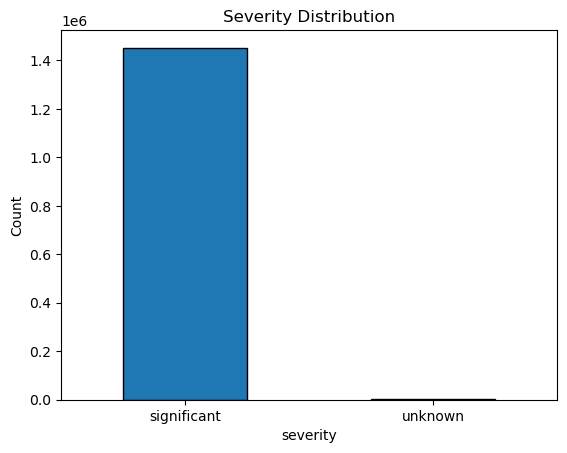

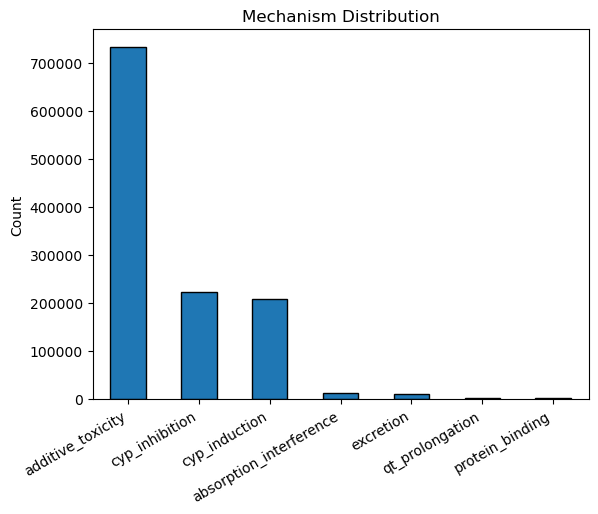

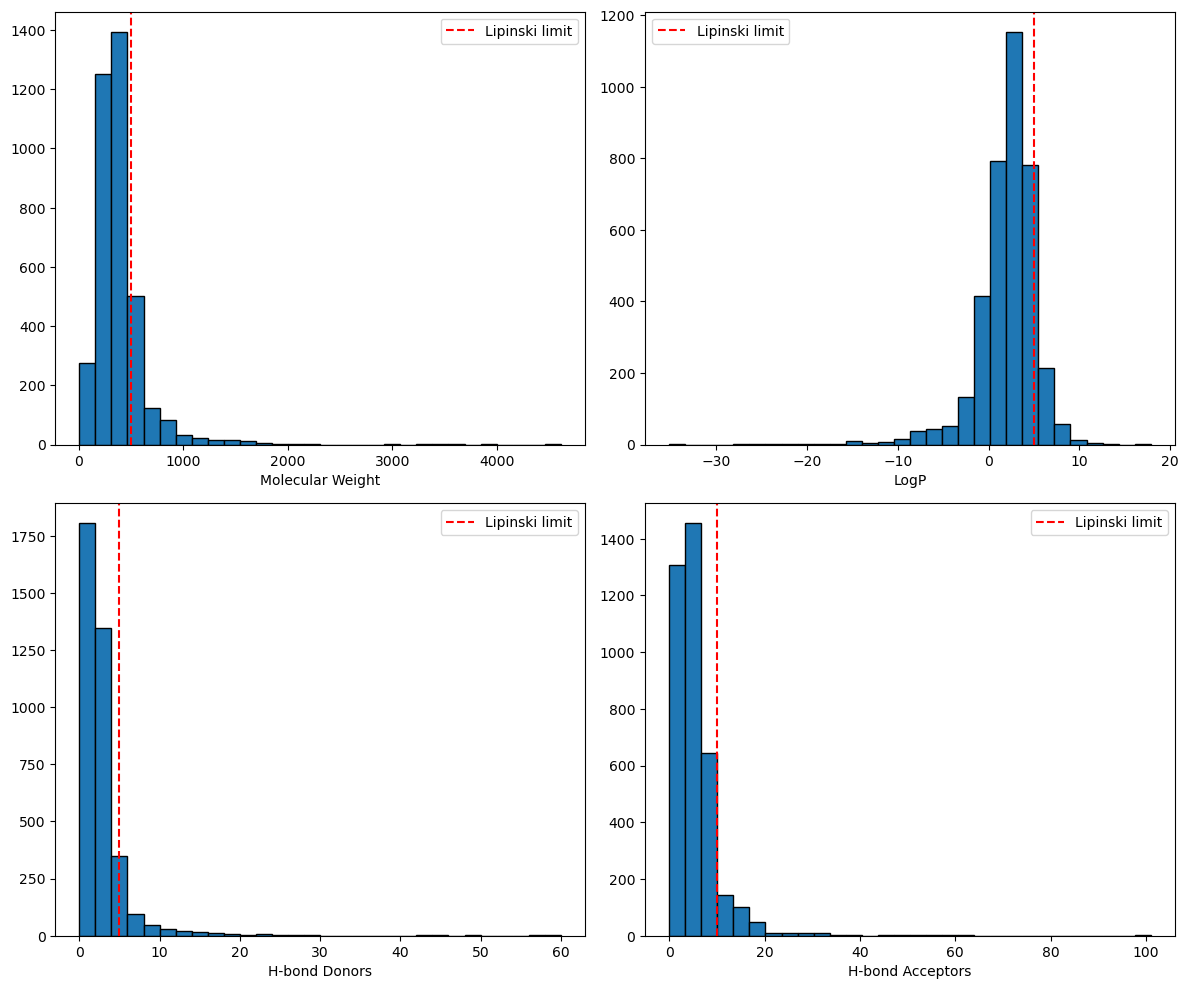

In [18]:
fig, ax = plt.subplots()
df_pairs["severity"].value_counts().plot(kind="bar", edgecolor="black", ax=ax)
ax.set_title("Severity Distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
fig.savefig(PLOTS / "severity_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots()
mech_counts.drop("other", errors="ignore").plot(kind="bar", edgecolor="black", ax=ax)
ax.set_title("Mechanism Distribution")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
fig.savefig(PLOTS / "mechanism_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (col, limit, label) in zip(axes.flat, [
    ("mw", 500, "Molecular Weight"), ("logp", 5, "LogP"),
    ("hbd", 5, "H-bond Donors"), ("hba", 10, "H-bond Acceptors"),
]):
    ax.hist(df_mol[col], bins=30, edgecolor="black")
    ax.axvline(limit, color="red", linestyle="--", label="Lipinski limit")
    ax.set_xlabel(label)
    ax.legend()
plt.tight_layout()
fig.savefig(PLOTS / "lipinski_properties.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## Save processed datasets

Write five CSVs: `ddi_pairs`, `drug_smiles`, `pk_features`, `tb_drug_ids`, `ddinter_matched`.

In [19]:
df_pairs.to_csv(PROCESSED / "ddi_pairs.csv", index=False)

pd.DataFrame([
    {"drugbank_id": d["drugbank_id"], "name": d["name"], "smiles": d["smiles"]}
    for d in drugs if d["smiles"] and d["drugbank_id"]
]).to_csv(PROCESSED / "drug_smiles.csv", index=False)

df_pk.to_csv(PROCESSED / "pk_features.csv")
if SAVE_LEGACY_PK:
    df_pk_full.to_csv(PROCESSED / "pk_features_30col_legacy.csv")

pd.Series(sorted(found.keys()), name="drugbank_id").to_csv(
    PROCESSED / "tb_drug_ids.csv", index=False)

dd.to_csv(PROCESSED / "ddinter_matched.csv", index=False)

print(f"Saved: ddi_pairs={len(df_pairs):,}  drug_smiles  "
      f"pk_features={df_pk.shape}  tb_drugs={len(found)}  "
      f"ddinter_matched={len(dd):,}")


Saved: ddi_pairs=1,456,772  drug_smiles  pk_features=(19853, 10)  tb_drugs=18  ddinter_matched=150,419


## Pipeline diagnostics

Reload via `ddi_merged()` and `split_pairs()` to mirror training. Per-TB-drug stage coverage, excluded-drug re-check, negative sampling validation, PK/SMILES coverage.

In [20]:
merged_pairs, _, _ = ddi_merged()
trn_split, val_split, tst_split = split_pairs(merged_pairs, seed=SEED)

MIN_TEST = 5


def drug_pair_count(df, did):
    return int(((df["drug_a"] == did) | (df["drug_b"] == did)).sum())


print(f"  {'Drug':<14s}  {'ID':<10s}  {'DrugBank':>9s}  {'DDInter':>8s}  "
      f"{'Merged':>7s}  {'Train':>6s}  {'Val':>5s}  {'Test':>5s}")

for tier, drugs_dict in TB_TIERS.items():
    print(f"\n{tier}")
    for did, name in drugs_dict.items():
        if did not in id_to_name:
            print(f"  {name:<14s}  {did:<10s}  not in DrugBank")
            continue
        db_n = drug_pair_count(df_pairs, did)
        dd_n = drug_pair_count(dd, did)
        mg_n = drug_pair_count(merged_pairs, did)
        tr_n = drug_pair_count(trn_split, did)
        vl_n = drug_pair_count(val_split, did)
        ts_n = drug_pair_count(tst_split, did)
        flag = " *" if ts_n < MIN_TEST else ""
        print(f"  {name:<14s}  {did:<10s}  {db_n:>9d}  {dd_n:>8d}  "
              f"{mg_n:>7d}  {tr_n:>6d}  {vl_n:>5d}  {ts_n:>5d}{flag}")

print(f"\n* = fewer than {MIN_TEST} test pairs")

  Drug            ID           DrugBank   DDInter   Merged   Train    Val   Test

FIRST_LINE
  Rifampin        DB01045          1163       246      193     161     16     16
  Isoniazid       DB00951          1822       230      144     113     17     14
  Ethambutol      DB00330          1234       110       37      24      8      5

SECOND_LINE
  Bedaquiline     DB08903           526       220       89      67     13      9
  Linezolid       DB00601          1525       252      143     109     15     19
  Moxifloxacin    DB00218           945       322      157     124     22     11
  Levofloxacin    DB01137          1432       420      299     238     20     41
  Clofazimine     DB00845           772       106       83      69      7      7
  Amikacin        DB00479           821       207      110      87      8     15

ARV_COADMIN
  Efavirenz       DB00625          1748       320      224     180     27     17
  Nevirapine      DB00238           882       204      106      91     

In [21]:
EXCLUDED_CANDIDATES = [
    "Pyrazinamide",           # first-line
    "Ethionamide",            # second-line
    "Cycloserine",            # second-line
    "Delamanid",              # newer TB
    "Pretomanid",             # newer TB
    "Tenofovir disoproxil",   # ARV
    "Dolutegravir",           # ARV
    "Emtricitabine",          # ARV
]

print(f"  {'Drug':<22s}  {'ID':<10s}  {'DrugBank':>9s}  {'Merged':>7s}  "
      f"{'Train':>6s}  {'Val':>5s}  {'Test':>5s}  {'Qualifies':>9s}")

qualifying = []
for name in EXCLUDED_CANDIDATES:
    did = name_to_id.get(name.lower())
    if did is None:
        print(f"  {name:<22s}  (not in DrugBank under this name)")
        continue
    db_n = drug_pair_count(df_pairs, did)
    mg_n = drug_pair_count(merged_pairs, did)
    tr_n = drug_pair_count(trn_split, did)
    vl_n = drug_pair_count(val_split, did)
    ts_n = drug_pair_count(tst_split, did)
    verdict = "yes" if ts_n >= MIN_TEST else "no"
    if ts_n >= MIN_TEST:
        qualifying.append((did, name, ts_n))
    print(f"  {name:<22s}  {did:<10s}  {db_n:>9d}  {mg_n:>7d}  "
          f"{tr_n:>6d}  {vl_n:>5d}  {ts_n:>5d}  {verdict:>9s}")

if qualifying:
    print(f"\n{len(qualifying)} now meet >={MIN_TEST} test pairs:")
    for did, name, n in qualifying:
        print(f"  {name} ({did}): {n}")
else:
    print(f"\nNo excluded drugs cross >={MIN_TEST} test pairs.")

  Drug                    ID           DrugBank   Merged   Train    Val   Test  Qualifies
  Pyrazinamide            DB00339           785        6       3      3      0         no
  Ethionamide             DB00609            85        2       2      0      0         no
  Cycloserine             DB00260           200        4       3      1      0         no
  Delamanid               DB11637           461        0       0      0      0         no
  Pretomanid              DB05154           680       11      10      1      0         no
  Tenofovir disoproxil    DB00300          1023        0       0      0      0         no
  Dolutegravir            DB08930           518       41      34      5      2         no
  Emtricitabine           DB00879            61        0       0      0      0         no

No excluded drugs cross >=5 test pairs.


In [22]:
def negative_drug_coverage(neg_df, documented_ids):
    """Breakdown of sampled negatives by drug-pair documentation status."""
    a_doc = neg_df["drug_a"].isin(documented_ids)
    b_doc = neg_df["drug_b"].isin(documented_ids)
    both = (a_doc & b_doc).sum()
    one = (a_doc ^ b_doc).sum()
    none = (~a_doc & ~b_doc).sum()
    n = len(neg_df)
    print(f"\nNegative coverage (n={n:,})")
    print(f"  both:    {both:>8,}  ({both / n:>5.1%})")
    print(f"  one:     {one:>8,}  ({one / n:>5.1%})")
    print(f"  neither: {none:>8,}  ({none / n:>5.1%})")


negs = negative_pairs(df_pairs, pair_ids, ratio=1.0, seed=SEED)
print(f"Positives: {len(df_pairs):,}  Negatives: {len(negs):,}")
possible = len(pair_ids) * (len(pair_ids) - 1) // 2
print(f"Possible: {possible:,}  Recorded: {len(df_pairs) / possible:.2%}")

documented = set(df_pairs["drug_a"]) | set(df_pairs["drug_b"])
negative_drug_coverage(negs, documented)


Positives: 1,456,772  Negatives: 1,456,772
Possible: 10,739,295  Recorded: 13.56%

Negative coverage (n=1,456,772)
  both:    1,456,772  (100.0%)
  one:            0  ( 0.0%)
  neither:        0  ( 0.0%)


In [23]:
ddi_drug_ids = set(df_pairs["drug_a"]) | set(df_pairs["drug_b"])
ddi_pk = df_pk.loc[df_pk.index.isin(ddi_drug_ids)]
ddi_annotated = (ddi_pk.sum(axis=1) > 0).sum()
print(f"PK coverage (DDI drugs): {ddi_annotated:,}/{len(ddi_pk):,} "
      f"({ddi_annotated / len(ddi_pk):.1%})")
print(f"SMILES coverage: {len(paired_smiles):,}/{len(pair_ids):,} "
      f"({len(paired_smiles) / len(pair_ids):.1%})")
print(f"Missing from PK matrix: {len(pair_ids - set(df_pk.index))}")


PK coverage (DDI drugs): 1,148/4,634 (24.8%)
SMILES coverage: 3,748/4,635 (80.9%)
Missing from PK matrix: 1


## SMILES collisions across DrugBank IDs

Salt forms, racemates, and prodrugs can share a canonical SMILES across distinct DrugBank IDs. Same molecule on both sides of a split is silent molecule-level leakage. Reports collision-class sizes.

In [24]:
def canonical_smiles(smi):
    """Canonical SMILES from RDKit, or None on parse failure."""
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol is not None else None


canon_lookup = {did: canonical_smiles(smi)
                for did, smi in paired_smiles.items()}
canon_lookup = {did: c for did, c in canon_lookup.items() if c is not None}

canon_to_ids = {}
for did, c in canon_lookup.items():
    canon_to_ids.setdefault(c, []).append(did)

groups = [ids for ids in canon_to_ids.values() if len(ids) > 1]
collision_ids = {did for ids in groups for did in ids}

print(f"Drugs with SMILES: {len(canon_lookup):,}")
print(f"Distinct canonicals: {len(canon_to_ids):,}")
print(f">=2 IDs share SMILES: {len(groups):,}")
print(f"IDs in collisions: {len(collision_ids):,}")
if groups:
    sizes = pd.Series([len(g) for g in groups]).value_counts().sort_index()
    print("\nGroup sizes:")
    for size, n in sizes.items():
        print(f"  {size} IDs: {n:>4d} groups")
    print("\nSample collisions:")
    for ids in groups[:5]:
        names = [id_to_name.get(d, "?") for d in ids]
        print(f"  {ids}  ->  {names}")


Drugs with SMILES: 3,747
Distinct canonicals: 3,747
>=2 IDs share SMILES: 0
IDs in collisions: 0


## TB-drug PK coverage by tier

PK annotation count per TB-tier drug. Zero-annotation drugs reduce GNN+PK to molecular structure alone, relevant for tier metrics in manuscript section 5.5.

In [25]:
def tb_pk_coverage(pk_df, tier_drugs, tier_name):
    """PK annotation count per drug in a TB tier."""
    rows = []
    for did, name in tier_drugs.items():
        if did not in pk_df.index:
            rows.append((name, did, "absent", 0))
            continue
        n = int(pk_df.loc[did].sum())
        status = "annotated" if n > 0 else "empty"
        rows.append((name, did, status, n))
    print(f"\n{tier_name}")
    print(f"  {'Drug':<14s}  {'ID':<10s}  {'Status':<10s}  {'Flags':>6s}")
    for name, did, status, n in rows:
        print(f"  {name:<14s}  {did:<10s}  {status:<10s}  {n:>6d}")
    annotated = sum(1 for _, _, s, _ in rows if s == "annotated")
    print(f"  annotated: {annotated}/{len(tier_drugs)}")


for tier_name, tier_drugs in TB_TIERS.items():
    tb_pk_coverage(df_pk, tier_drugs, tier_name)



FIRST_LINE
  Drug            ID          Status       Flags
  Rifampin        DB01045     annotated        1
  Isoniazid       DB00951     annotated        1
  Ethambutol      DB00330     empty            0
  annotated: 2/3

SECOND_LINE
  Drug            ID          Status       Flags
  Bedaquiline     DB08903     annotated        1
  Linezolid       DB00601     empty            0
  Moxifloxacin    DB00218     empty            0
  Levofloxacin    DB01137     empty            0
  Clofazimine     DB00845     empty            0
  Amikacin        DB00479     empty            0
  annotated: 1/6

ARV_COADMIN
  Drug            ID          Status       Flags
  Efavirenz       DB00625     annotated        3
  Nevirapine      DB00238     annotated        3
  Ritonavir       DB00503     annotated        3
  Atazanavir      DB01072     annotated        3
  Lopinavir       DB01601     annotated        4
  annotated: 5/5

COMEDICATIONS
  Drug            ID          Status       Flags
  Fluconazole 

## Cross-database overlap diagnostic

Why interactions can fail to merge even when names resolve. Three causes: (1) drug absent from DDInter, (2) partner names fail to map, (3) curation-scope divergence (both DBs carry the drug but record non-overlapping partners). Case 3 is a finding, not a bug.

In [26]:
for target in ["tenofovir", "emtricitabine", "delamanid"]:
    hits = dd_raw[
        dd_raw["Drug_A"].str.lower().str.contains(target, na=False)
        | dd_raw["Drug_B"].str.lower().str.contains(target, na=False)
    ]
    if len(hits) == 0:
        print(f"{target}: not in DDInter")
        continue
    names = pd.concat([hits["Drug_A"], hits["Drug_B"]])
    names = names[names.str.lower().str.contains(target, na=False)]
    print(f"{target}: {len(hits)} rows, names:")
    print(names.value_counts().head(5).to_string())


tenofovir: not in DDInter
emtricitabine: 20 rows, names:
Emtricitabine    20
delamanid: not in DDInter


In [27]:
target_id = "DB00879"
target_name = "emtricitabine"

target_rows = dd_raw[
    (dd_raw["Drug_A"].str.lower() == target_name)
    | (dd_raw["Drug_B"].str.lower() == target_name)
]
print(f"{target_name} DDInter rows: {len(target_rows)}")
print(target_rows["Level"].value_counts().to_string())

a_norm = normalized_names(target_rows["Drug_A"])
b_norm = normalized_names(target_rows["Drug_B"])
a_mapped = a_norm.map(db_index)
b_mapped = b_norm.map(db_index)
both_mapped = a_mapped.notna() & b_mapped.notna()
print(f"\nBoth mapped: {both_mapped.sum()}/{len(target_rows)}")

if (~both_mapped).any():
    unmapped_partners = pd.concat([
        a_norm[~a_mapped.notna()],
        b_norm[~b_mapped.notna()],
    ])
    print(f"Unmapped partners ({len(unmapped_partners)}):")
    print(unmapped_partners.value_counts().head(10).to_string())

in_pairs = (
    (df_pairs["drug_a"] == target_id) | (df_pairs["drug_b"] == target_id)
).sum()
print(f"\n{target_name} in df_pairs: {in_pairs}")

has_smiles = target_id in smiles_lookup
has_pk = target_id in df_pk.index
pk_annotated = bool(df_pk.loc[target_id].sum()) if has_pk else False
print(f"{target_name}: SMILES={has_smiles}  PK={has_pk}  annotated={pk_annotated}")


emtricitabine DDInter rows: 20
Level
Moderate    17
Major        2
Minor        1

Both mapped: 20/20

emtricitabine in df_pairs: 61
emtricitabine: SMILES=True  PK=True  annotated=False


In [28]:
dd_mapped = matched_pairs(target_rows, db_index)
print(f"{target_name} mapped pairs: {len(dd_mapped)}")

dd_strict = set(zip(dd_mapped["drug_a"], dd_mapped["drug_b"]))
dd_canon = {tuple(sorted(p)) for p in dd_strict}

db_strict = set(zip(df_pairs["drug_a"], df_pairs["drug_b"]))
db_canon = {tuple(sorted(p)) for p in db_strict}

print(f"Strict overlap:    {len(dd_strict & db_strict)}")
print(f"Reverse overlap:   {len(dd_strict & {(b, a) for a, b in db_strict})}")
print(f"Canonical overlap: {len(dd_canon & db_canon)}")

missed = dd_canon - db_canon
if missed:
    print(f"\nDDInter-only pairs ({len(missed)}):")
    for a, b in sorted(missed)[:10]:
        print(f"  ({a}, {b})")


emtricitabine mapped pairs: 20
Strict overlap:    0
Reverse overlap:   0
Canonical overlap: 0

DDInter-only pairs (20):
  (DB00023, DB00879)
  (DB00059, DB00879)
  (DB00060, DB00879)
  (DB00068, DB00879)
  (DB00242, DB00879)
  (DB00352, DB00879)
  (DB00445, DB00879)
  (DB00563, DB00879)
  (DB00631, DB00879)
  (DB00704, DB00879)


## PK leakage check on cached predictions

For each cached model, compare mechanism AUROC/AUPRC on pairs where the corresponding leakage-prone PK flag is set vs absent. Positive `AUPRC_gap` means the model gains from the leaked signal. Requires `evaluate.py` and `baseline_eval.py` to have been run; queries the in-memory 30-col `df_pk_full` (not the on-disk 10-col clean version).

In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score

PREDICTIONS_DIR = cfg.paths.metrics.parent / "predictions"
MECH_NAMES = cfg.data.mechanism_cols
MIN_POS_PARTITION = 5


def cached_models():
    """Model names with mechanism predictions cached on disk."""
    if not PREDICTIONS_DIR.exists():
        return []
    out = []
    for p in sorted(PREDICTIONS_DIR.glob("*.npz")):
        with np.load(p, allow_pickle=True) as data:
            if "tst_mech_probs" in data.files:
                out.append(p.stem)
    return out


def test_predictions(model_name):
    """Test-pair frame, mechanism prediction probs, and labels."""
    data = np.load(PREDICTIONS_DIR / f"{model_name}.npz", allow_pickle=True)
    pairs = pd.DataFrame({"drug_a": data["tst_drug_a"],
                          "drug_b": data["tst_drug_b"]})
    return pairs, data["tst_mech_probs"], data["tst_mech_labels"]


def partition_scores(probs, labels, flag_mask):
    """AUROC and AUPRC on flag-present and flag-absent partitions."""
    out = {}
    for tag, mask in [("present", flag_mask), ("absent", ~flag_mask)]:
        n_pos = int(labels[mask].sum())
        if n_pos < MIN_POS_PARTITION or n_pos == int(mask.sum()):
            out[tag] = {"n": int(mask.sum()), "n_pos": n_pos,
                        "auroc": None, "auprc": None}
            continue
        out[tag] = {
            "n": int(mask.sum()), "n_pos": n_pos,
            "auroc": float(roc_auc_score(labels[mask], probs[mask])),
            "auprc": float(average_precision_score(labels[mask], probs[mask])),
        }
    return out


def leakage_partition_table(model_name, pk_df, mech_to_pk):
    """Per-mechanism AUROC and AUPRC by PK leakage exposure."""
    pairs, mech_probs, mech_labels = test_predictions(model_name)
    print(f"\n{model_name}  (n={len(pairs):,} test pairs)")
    print(f"  {'mechanism':<25s}  {'partition':<15s}  {'n':>6s}  "
          f"{'n_pos':>6s}  {'AUROC':>7s}  {'AUPRC':>7s}  {'AUPRC_gap':>10s}")
    for mech, cols in mech_to_pk.items():
        if not cols or mech not in MECH_NAMES:
            continue
        idx = MECH_NAMES.index(mech)
        flag = pair_has_flag(pairs, pk_df, cols).values
        scores = partition_scores(mech_probs[:, idx], mech_labels[:, idx], flag)
        present, absent = scores["present"], scores["absent"]
        if present["auprc"] is not None and absent["auprc"] is not None:
            gap_str = f"{present['auprc'] - absent['auprc']:+.4f}"
        else:
            gap_str = "n/a"
        for tag, label in [("present", "PK flag set"),
                           ("absent", "PK flag absent")]:
            m = scores[tag]
            auroc = f"{m['auroc']:.4f}" if m["auroc"] is not None else "n/a"
            auprc = f"{m['auprc']:.4f}" if m["auprc"] is not None else "n/a"
            shown = gap_str if tag == "present" else ""
            print(f"  {mech:<25s}  {label:<15s}  {m['n']:>6d}  "
                  f"{m['n_pos']:>6d}  {auroc:>7s}  {auprc:>7s}  {shown:>10s}")


models = cached_models()
if not models:
    print(f"No cached predictions in {PREDICTIONS_DIR}. "
          f"Run evaluate.py and baseline_eval.py first.")
else:
    print(f"Cached models: {', '.join(models)}")
    print("AUPRC_gap = AUPRC(PK flag set) - AUPRC(PK flag absent); "
          "positive = leakage boost.")
    for name in models:
        leakage_partition_table(name, df_pk_full, MECHANISM_TO_PK)


Cached models: ablation_gnn_only, ablation_pk_only, gnn, mlp, rf, xgb
AUPRC_gap = AUPRC(PK flag set) - AUPRC(PK flag absent); positive = leakage boost.

ablation_gnn_only  (n=13,002 test pairs)
  mechanism                  partition             n   n_pos    AUROC    AUPRC   AUPRC_gap
  cyp_induction              PK flag set        2366     672   0.8277   0.6898     +0.1596
  cyp_induction              PK flag absent    10636     504   0.9311   0.5302            
  cyp_inhibition             PK flag set        5083    1906   0.8445   0.7546     +0.3329
  cyp_inhibition             PK flag absent     7919     140   0.9477   0.4217            
  absorption_interference    PK flag set        3288      46   0.8899   0.4925     -0.2681
  absorption_interference    PK flag absent     9714      90   0.9939   0.7606            
  excretion                  PK flag set        3660      25   0.8042   0.0444     +0.0279
  excretion                  PK flag absent     9342       7   0.9262   0.0165

In [30]:
def dropout_diagnostic(dd_df, db_index, aliases):
    raw = dd_df.copy()
    def norm_noalias(s):
        return s.str.replace(r"\s*\(.*?\)", "", regex=True).str.strip().str.lower()
    a0, b0 = norm_noalias(raw["Drug_A"]), norm_noalias(raw["Drug_B"])
    matched_exact = a0.isin(db_index) & b0.isin(db_index)
    dropped = raw[~matched_exact]
    print(f"exact-match dropped: {len(dropped):,}  "
          f"({len(dropped)/len(raw):.2%} of DDInter raw {len(raw):,})")
    for src, tgt in aliases.items():
        rec = dropped[(a0[~matched_exact] == src) | (b0[~matched_exact] == src)]
        print(f"  alias {src!r} -> {tgt!r}: recovers {len(rec):,}")
    a1 = a0.replace(aliases); b1 = b0.replace(aliases)
    still = ~(a1.isin(db_index) & b1.isin(db_index)) & ~matched_exact
    print(f"still unmatched after aliases: {int(still.sum()):,}")

dropout_diagnostic(dd_raw, db_index, DDINTER_ALIASES)

exact-match dropped: 1,824  (0.82% of DDInter raw 222,383)
  alias 'rifampicin' -> 'rifampin': recovers 284
  alias 'salbutamol' -> 'albuterol': recovers 1,104
  alias 'interferon alfa-2a, recombinant' -> 'interferon alfa-2a': recovers 231
  alias 'pfizer-biontech covid-19 vaccine' -> 'tozinameran': recovers 204
still unmatched after aliases: 2


In [32]:
def pgp_recovery_count(drugs):
    old_substr = "p-glycoprotein 1"
    correct = "ATP-dependent translocase ABCB1"
    recovered = 0
    for d in drugs:
        tr = d.get("transporters", {})
        keys = {k.lower(): k for k in tr}
        has_correct = correct.lower() in keys and len(tr[keys[correct.lower()]]) > 0
        has_old = any(old_substr in k for k in keys)
        if has_correct and not has_old:
            recovered += 1
    print(f"drugs with ABCB1 under correct label, missed by old substring: {recovered}")
    print(f"rifampin (DB01045) among them: "
          f"{'yes' if any(d.get('drugbank_id')=='DB01045' for d in drugs) else 'check'}")

pgp_recovery_count(drugs)

drugs with ABCB1 under correct label, missed by old substring: 591
rifampin (DB01045) among them: yes


In [31]:
print(f"Notebook time: {(time.time() - notebook_start) / 60:.1f} min")

Notebook time: 1.7 min
